In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
mouse_day = {25: [25],
             26: [19],
             28: [25]}
fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
# 21: [16] M21 doesn't really work for because the grid scale appears to be too large.

25 25
optimal travel lag is 5.755755755755757 cm based on kde of travel at max spatial information
optimal travel lag is 5.755755755755757 cm
there are 110 non_grid and non_spatial_cells
there are 36 grid_cells
there are 74 non grid spatial cells
there are 36 non spatial cells
there are 0 speed cells
there are 146 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl1' 'VISpl2/3']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl2/3']
unique brain regions ['ENTm2' 'ENTm3' 'PAR' 'VISpl1' 'VISpl2/3']
there are 64 MEC cells
there are 49 PARA cells
there are 0 PRE cells
there are 39 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 152 all cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 14.931271762229468
Found 3 modules with HDBSCAN for mouse 25 day 25
for

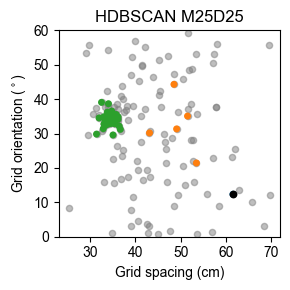

for module 0, there are 5 cells with average spacing 49.153961296236965
for module 1, there are 30 cells with average spacing 34.29724377249578
module 1 contains cells from ['ENTm2' 'PAR' 'VISpl2/3']
module 0 contains cells from ['ENTm2' 'PAR' 'VISpl2/3']
25 25
for module 1, there are 30 cells
for module 0, there are 5 cells
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


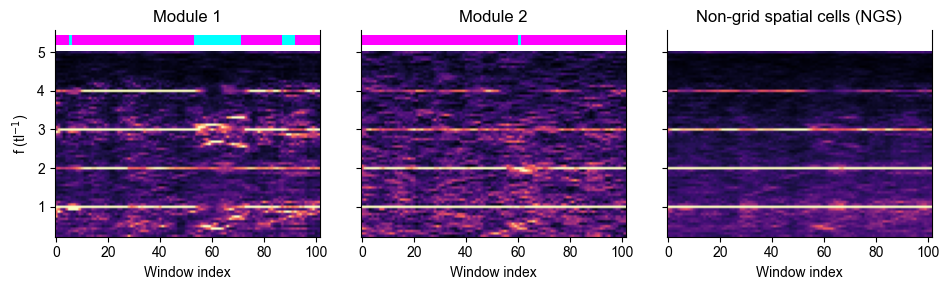

Identified 1 candidate modules
Mean probe_x: 356.60, Mean probe_y: 2356.00
26 19
optimal travel lag is 9.45945945945946 cm based on kde of travel at max spatial information
optimal travel lag is 9.45945945945946 cm
there are 315 non_grid and non_spatial_cells
there are 29 grid_cells
there are 268 non grid spatial cells
there are 47 non spatial cells
there are 0 speed cells
there are 344 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpor5']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl5']
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpor5']
there are 265 MEC cells
there are 19 PARA cells
there are 0 PRE cells
there are 62 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 346 all cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not mergi

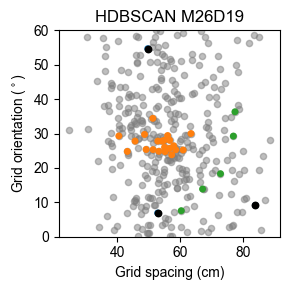

for module 0, there are 21 cells with average spacing 53.41672002112407
for module 1, there are 5 cells with average spacing 70.905851926339
module 0 contains cells from ['ENTm2' 'ENTm3' 'PAR']
module 1 contains cells from ['ENTm2' 'ENTm3' 'PAR' 'VISpl5']
26 19
for module 0, there are 21 cells
for module 1, there are 5 cells
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


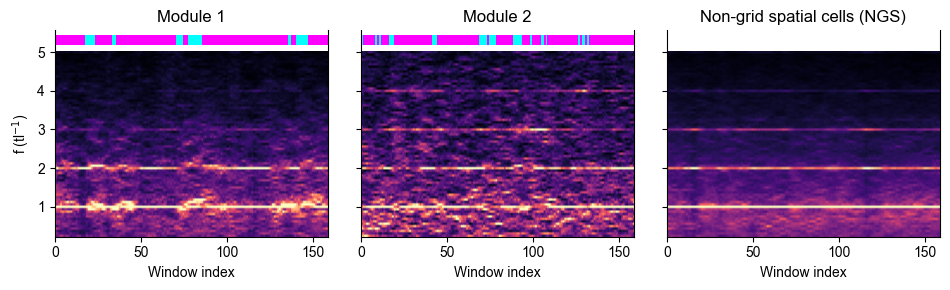

Identified 1 candidate modules
Mean probe_x: 272.86, Mean probe_y: 1032.14
28 25
optimal travel lag is 9.75975975975976 cm based on kde of travel at max spatial information
optimal travel lag is 9.75975975975976 cm
there are 106 non_grid and non_spatial_cells
there are 23 grid_cells
there are 94 non grid spatial cells
there are 12 non spatial cells
there are 0 speed cells
there are 129 cells
for the non-grid spatial cells the unique locations are ['ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpl6a' 'VISpor5']
for the grid cells the unique locations are ['ENTm3' 'ENTm5']
unique brain regions ['ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpl6a' 'VISpor5']
there are 95 MEC cells
there are 30 PARA cells
there are 0 PRE cells
there are 13 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 138 all cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distan

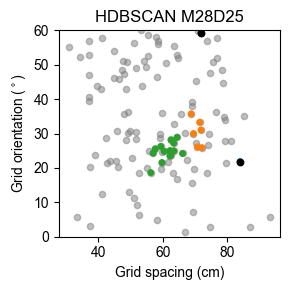

for module 0, there are 6 cells with average spacing 70.76972276610992
for module 1, there are 15 cells with average spacing 61.33629235763494
module 1 contains cells from ['ENTm3' 'ENTm5']
module 0 contains cells from ['ENTm3' 'ENTm5']
28 25
for module 1, there are 15 cells
for module 0, there are 6 cells
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


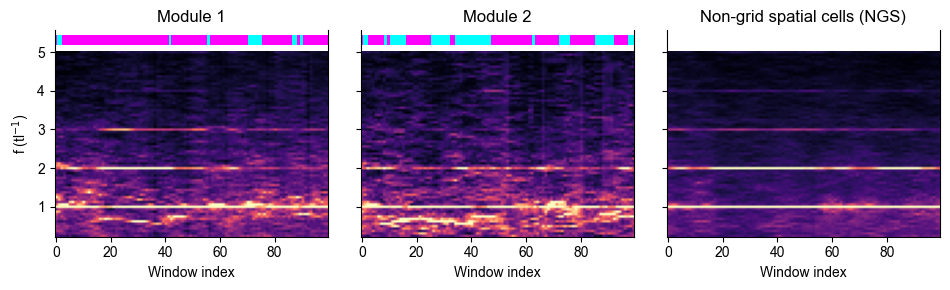

Identified 1 candidate modules
Mean probe_x: 290.13, Mean probe_y: 1014.00


In [3]:
mice = []
days = []
ids = []
cell_identities = []
sse_values = []
sse_values_minus_shuffle = []
sig_cells = []

for mouse, days_ in mouse_day.items():
    for day in days_:
        
        gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
        #rc, rsc, vr_ns = cell_classification_vr(mouse, day)
        _, _, _, _, _, _, _, all_by_anatomy = cell_classification_anatomy(mouse,day)
        g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                        figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True) # create grid modules using HDBSCAN    
        tcs,tcs_time,_,last_ephys_bin,_,_ = compute_vr_tcs(mouse, day)

        plot_grid_modules_rate_maps(gcs, g_m_ids, g_m_cluster_ids, mouse, day, figpath=fig_path)

        # we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
        # as defined by activity in the open field
        g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
        cluster_ids_by_group = []
        cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
        cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
        cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
        cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
        cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]


        fig, ax = plt.subplots(nrows=1, ncols=len(g_m_cluster_ids)+1, figsize=(3.2*(len(g_m_cluster_ids)+1), 3), squeeze=False, sharey=True)
        peak_indices = [28, 44, 60, 76]

        for m in range(len(g_m_cluster_ids)):
            cluster_ids = g_m_cluster_ids[m]
            tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
            results = spectral_analysis(tcs_to_use, tl, bs=bs)
            spectrograms = results[3]
            fvalid = results[5]

            S = spectrograms.mean(0)
            ax[0, m].set_title(f'Module {m+1}')
            ax[0, m].imshow(S, origin='lower', aspect='auto', vmax=0.25, cmap='magma')
            max_peaks = np.argmax(S, axis=0)
            peak_indices = [12, 28, 44, 60, 76]
            ax[0, m].set_yticks(peak_indices)
            ax[0, m].set_yticklabels([1, 2, 3, 4, 5])
            ax[0, m].spines['top'].set_visible(False)
            ax[0, m].set_xlabel('Window index')

            # Cluster labels: 1 if max at peak_indices_gm, else 0
            labels = np.isin(max_peaks, peak_indices).astype(int)
            ax[0, m].scatter(
                np.arange(S.shape[1]),
                np.full(S.shape[1], 81),  # y just above the top
                c=labels,
                cmap='cool',
                marker='s',
                s=50,
                vmin=0,
                vmax=1,
                edgecolor='none',
                clip_on=True
            )

        # Non-grid spatial
        tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs}
        results = spectral_analysis(tcs_to_use, tl, bs=bs)
        spectrograms = results[3]
        S = spectrograms.mean(0)

        ax[0, -1].set_title('Non-grid spatial cells (NGS)')
        ax[0, -1].imshow(S, origin='lower', aspect='auto', vmax=0.25, cmap='magma')
        max_peaks = np.argmax(S, axis=0)
        peak_indices = [12, 28, 44, 60, 76]
        ax[0, -1].set_yticks(peak_indices)
        ax[0, -1].set_yticklabels([1, 2, 3, 4, 5])
        ax[0, 0].set_ylabel(r'f (tl$^{-1}$)')
        ax[0, -1].set_xlabel('Window index')
        ax[0, -1].spines['top'].set_visible(False)
        labels = np.isin(max_peaks, peak_indices).astype(int)
        ax[0, -1].scatter(
            np.arange(S.shape[1]),
            np.full(S.shape[1], 81),  # y just above the top
            c=labels,
            cmap='cool',
            marker='s',
            vmin=0,
            vmax=1,
            s=50,
            alpha=0,
            edgecolor='none',
            clip_on=True
        )

        plt.tight_layout(w_pad=2)
        plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/M{mouse}D{day}_joint_spectrograms.pdf', bbox_inches='tight')
        plt.show()

        # Now identify significant cells within each group
        # We will use a shuffle method to identify cells with significant differences in rate maps between the
        # two trial types defined by the spectrogram peak analysis.
        # We will use the sum of squared error (SSE) between the two rate maps as the metric.
        # Cells with SSE greater than the 99th percentile of the null distribution will be considered significant.
        # The null distribution is generated by shuffling the trial labels 100 times and computing the SSE for each shuffle.
        # This approach avoids issues with low firing rates and zero rates in some bins.
        # It also avoids the need for fold change, which can be problematic with low rates.
        # Instead, we focus on the absolute difference in rate maps as captured by the SSE.
        # This method is more robust and interpretable in the context of spatial firing rate maps.

        # For each cell, compute the sum of squared error (SSE) between task-anchored and task-independent rate maps,
        # and use this as the metric instead of fold change.
        cluster_ids = g_m_cluster_ids[0]
        tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
        results = spectral_analysis(tcs_to_use, tl, bs=bs)
        spectrograms = results[3] 
        S = spectrograms.mean(0)
        max_peaks = np.argmax(S, axis=0)
        labels = np.isin(max_peaks, peak_indices).astype(int) # using module 1 peaks as labels

        # Calculate mean probe_x and probe_y for cluster_ids in g_m_cluster_ids[0]
        cluster_ids = g_m_cluster_ids[0]
        subset = all[all['cluster_id'].isin(cluster_ids)]
        mean_x = subset['probe_x'].mean()
        mean_y = subset['probe_y'].mean()
        print(f"Mean probe_x: {mean_x:.2f}, Mean probe_y: {mean_y:.2f}")

        # Determine shank associated with mean_x
        mean_shank = int(np.round(mean_x / 250))

        n_shuffles = 100  # Number of shuffles for null distribution
        tcs, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs(mouse, day, apply_zscore=False)

        for idx, id in enumerate(all.cluster_id.values):
            tc = tcs[id]
            tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
            tc = tc[:last_ephys_bin]
            tcz = zscore(tc)
            bin_config = get_bin_config('VR')
            trial_labels = get_kmeans_spatial_labels(tcz, labels, bs=bs, tl=tl)
            trials = beh['trials'][:len(trial_labels)]

            # Real rate maps
            x0, y0 = get_avg_profile(tcz, bs, tl, mask=trial_labels == 0)
            x1, y1 = get_avg_profile(tcz, bs, tl, mask=trial_labels == 1)

            # Ensure same length for SSE calculation
            min_len = min(len(y0), len(y1))
            y0 = y0[:min_len]
            y1 = y1[:min_len]
            sse_real = np.sum((y1 - y0) ** 2)
            sse_values.append(sse_real)

            # Null distribution by shuffling
            sse_shuffles = []
            for _ in range(n_shuffles):
                shuffled = np.random.permutation(trial_labels)
                x0s, y0s = get_avg_profile(tcz, bs, tl, mask=shuffled == 0)
                x1s, y1s = get_avg_profile(tcz, bs, tl, mask=shuffled == 1)
                min_len_shuf = min(len(y0s), len(y1s))
                if min_len_shuf > 0:
                    y0s = y0s[:min_len_shuf]
                    y1s = y1s[:min_len_shuf]
                    sse_shuffles.append(np.sum((y1s - y0s) ** 2))
                else:
                    sse_shuffles.append(np.nan)
            sse_shuffles = np.array(sse_shuffles)
            p99 = np.nanpercentile(sse_shuffles, 99)
            sig_cells.append(sse_real > p99)
            sse_values_minus_shuffle.append(sse_real - p99)


            probe_x = all[all.cluster_id == id].probe_x.values[0]
            probe_y = all[all.cluster_id == id].probe_y.values[0]
            s = probe_x // 250
            # Assign cell identity
            if id in cluster_ids:
                cell_identities.append('Module 1')
            elif id in ngs.cluster_id.values:
                # Assign based on shank relative to mean_shank
                if s < mean_shank:
                    cell_identities.append('medial shank')
                elif s == mean_shank:
                    cell_identities.append('same shank')
                else:
                    cell_identities.append('lateral shank')
            else:
                cell_identities.append('Other')

            mice.append(mouse)
            days.append(day)
            ids.append(id)

mice = np.array(mice)
days = np.array(days)
ids = np.array(ids)
cell_identities = np.array(cell_identities)
sse_values = np.array(sse_values)
sig_cells = np.array(sig_cells)


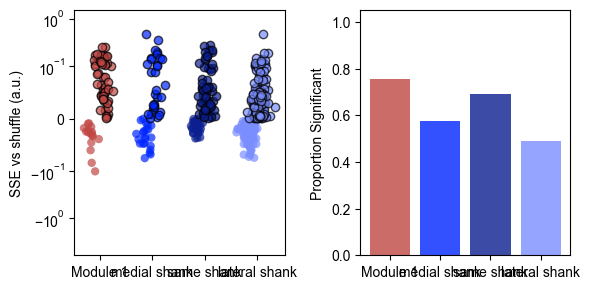

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create DataFrame
df = pd.DataFrame({
    'mouse': mice,
    'day': days,
    'id': ids,
    'CellIdentity': cell_identities,
    'SSE': sse_values,
    'SSE_minus_shuffle': sse_values_minus_shuffle,
    'Significant': sig_cells
})

# Remove missing values
df = df.dropna()

# Only keep cmGC, ncmGC, NGS
order = ['Module 1', 'medial shank', 'same shank', 'lateral shank']
df = df[df['CellIdentity'].isin(order)]
    
# Set colors (from previous usage)
colors = ["#c04744","#0026ff", "#0b1f90", "#7a8eff"]  # Module 1, Shank 1-4

# Calculate proportion significant for each cell type (in order)
proportions = df.groupby('CellIdentity')['Significant'].mean().reindex(order)

# Jitter plot with sig/non-sig separation
plt.figure(figsize=(6, 3))
cell_types = order
plt.subplot(1, 2, 1)
for i, ct in enumerate(cell_types):
    subset = df[df['CellIdentity'] == ct]
    sig_mask = subset['Significant']
    # Non-significant: slightly left
    x_non_sig = np.random.normal(i - 0.15, 0.08, size=np.sum(~sig_mask))
    plt.scatter(x_non_sig, subset.loc[~sig_mask, 'SSE_minus_shuffle']/(tl/bs), 
                c=colors[i], edgecolors='none', alpha=0.7, label=f'{ct} non-sig')
    # Significant: centered
    x_sig = np.random.normal(i + 0.05, 0.08, size=np.sum(sig_mask))
    plt.scatter(x_sig, subset.loc[sig_mask, 'SSE_minus_shuffle']/(tl/bs), 
                c=colors[i], edgecolors='black', alpha=0.7, label=f'{ct} sig')
plt.xticks(range(len(cell_types)), cell_types)
plt.ylabel('SSE vs shuffle (a.u.)')
plt.xlabel('')
plt.ylim(-6, 1.5)
plt.yscale('symlog', linthresh=0.1)

# Bar plot for proportion significant
plt.subplot(1, 2, 2)
plt.bar(proportions.index, proportions.values, color=colors, alpha=0.8)
plt.ylabel('Proportion Significant')
plt.xlabel('')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/Population_spectrogram_summary_multishank.pdf', bbox_inches='tight')
plt.show()

In [5]:
df

,mouse,day,id,CellIdentity,SSE,SSE_minus_shuffle,Significant
0,25,25,1,medial shank,20.877403,15.051027,True
1,25,25,3,Module 1,11.748382,6.411322,True
6,25,25,13,medial shank,7.827186,2.431868,True
7,25,25,14,Module 1,21.350390,16.408843,True
8,25,25,15,Module 1,9.723332,4.676081,True
...,...,...,...,...,...,...,...
613,28,25,461,lateral shank,3.154783,-3.374527,False
614,28,25,462,lateral shank,20.669958,11.791780,True
615,28,25,476,lateral shank,20.487063,12.712704,True
616,28,25,478,lateral shank,7.237946,-6.618120,False


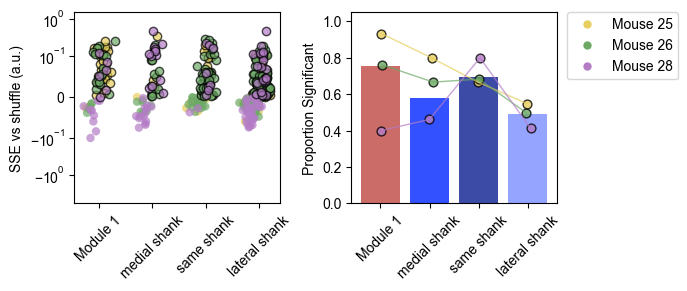

: 

In [ ]:
import matplotlib.pyplot as plt

# Choose colors that are not red or blue
custom_colors = [
    "#e6cf5c",  # orange
    "#6ca965",  # green
    "#b47cc7",  # purple
    "#a97c50",  # brown
]

unique_mice = np.sort(df['mouse'].unique())
mouse_color_dict = {mouse: custom_colors[i % len(custom_colors)] for i, mouse in enumerate(unique_mice)}

plt.figure(figsize=(7, 3))

# Left plot: jitter scatter
plt.subplot(1, 2, 1)
for i, ct in enumerate(cell_types):
    subset = df[df['CellIdentity'] == ct]
    sig_mask = subset['Significant']
    for mouse in unique_mice:
        mouse_subset = subset[subset['mouse'] == mouse]
        mouse_sig_mask = mouse_subset['Significant']
        # Non-significant: slightly left
        x_non_sig = np.random.normal(i - 0.15, 0.08, size=np.sum(~mouse_sig_mask))
        plt.scatter(x_non_sig, mouse_subset.loc[~mouse_sig_mask, 'SSE_minus_shuffle']/(tl/bs),
                    c=[mouse_color_dict[mouse]], edgecolors='none', alpha=0.7, label=f'Mouse {mouse}' if i == 0 else None)
        # Significant: centered
        x_sig = np.random.normal(i + 0.05, 0.08, size=np.sum(mouse_sig_mask))
        plt.scatter(x_sig, mouse_subset.loc[mouse_sig_mask, 'SSE_minus_shuffle']/(tl/bs),
                    c=[mouse_color_dict[mouse]], edgecolors='black', alpha=0.7)
plt.xticks(range(len(cell_types)), cell_types, rotation=45)
plt.ylabel('SSE vs shuffle (a.u.)')
plt.xlabel('')
plt.ylim(-6, 1.5)
plt.yscale('symlog', linthresh=0.1)

# Right plot: bar and overlay
plt.subplot(1, 2, 2)
plt.bar(proportions.index, proportions.values, color=colors, alpha=0.8)
plt.ylabel('Proportion Significant')
plt.xlabel('')
plt.ylim(0, 1.05)

# Overlay scatter points: proportion significant for each mouse-day-celltype
grouped = df.groupby(['mouse', 'day', 'CellIdentity'])['Significant'].mean().reset_index()
for (mouse, day), md_group in grouped.groupby(['mouse', 'day']):
    x_points = []
    y_points = []
    for i, ct in enumerate(order):
        ct_group = md_group[md_group['CellIdentity'] == ct]
        # Use mean for y, single jittered x for each cell type
        if len(ct_group) > 0:
            x_jitter = np.random.normal(i, 0.04)
            y_mean = ct_group['Significant'].mean()
            plt.scatter([x_jitter], [y_mean],
                        c=[mouse_color_dict[mouse]],
                        edgecolors='black', alpha=0.8, s=40, label=None)
            x_points.append(x_jitter)
            y_points.append(y_mean)
    # Connect means for this mouse-day pair
    if len(x_points) == len(order):
        plt.plot(x_points, y_points, color=mouse_color_dict[mouse], alpha=0.7, linewidth=1)
# Move legend to the right of the rightmost plot
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=mouse_color_dict[m], label=f'Mouse {m}', markersize=7) for m in unique_mice]
plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.xticks(range(len(cell_types)), cell_types, rotation=45)
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/Population_spectrogram_summary_mouse_colored_multishank.pdf', bbox_inches='tight')
plt.show()

In [7]:
df

,mouse,day,id,CellIdentity,SSE,SSE_minus_shuffle,Significant
1,21,16,1,Shank 1,10.108309,-16.171435,False
2,21,16,6,Shank 1,10.036252,-12.150528,False
3,21,16,8,Shank 1,7.528285,-14.095949,False
4,21,16,9,Shank 1,27.743548,2.770194,True
5,21,16,10,Shank 1,42.779952,15.443808,True
...,...,...,...,...,...,...,...
844,28,25,461,Shank 4,3.154783,-3.708318,False
845,28,25,462,Shank 4,20.669958,15.546426,True
846,28,25,476,Shank 4,20.487063,12.028977,True
847,28,25,478,Shank 4,7.237946,-11.892235,False


In [ ]:
# For each cell, compute the sum of squared error (SSE) between task-anchored and task-independent rate maps,
# and use this as the metric instead of fold change.
cluster_ids = g_m_cluster_ids[0]
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3] 
S = spectrograms.mean(0)
max_peaks = np.argmax(S, axis=0)
labels = np.isin(max_peaks, peak_indices).astype(int) # using module 1 peaks as labels


sse_values = []
sig_cells = []

n_shuffles = 100  # Number of shuffles for null distribution
tcs, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs(mouse, day, apply_zscore=False)

for idx, id in enumerate(all.cluster_id.values):
    tc = tcs[id]
    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
    tc = tc[:last_ephys_bin]
    tcz = zscore(tc)
    bin_config = get_bin_config('VR')
    trial_labels = get_kmeans_spatial_labels(tcz, labels, bs=bs, tl=tl)
    trials = beh['trials'][:len(trial_labels)]

    # Real rate maps
    x0, y0 = get_avg_profile(tcz, bs, tl, mask=trial_labels == 0)
    x1, y1 = get_avg_profile(tcz, bs, tl, mask=trial_labels == 1)

    # Ensure same length for SSE calculation
    min_len = min(len(y0), len(y1))
    y0 = y0[:min_len]
    y1 = y1[:min_len]
    sse_real = np.sum((y1 - y0) ** 2)
    sse_values.append(sse_real)

    # Null distribution by shuffling
    sse_shuffles = []
    for _ in range(n_shuffles):
        shuffled = np.random.permutation(trial_labels)
        x0s, y0s = get_avg_profile(tcz, bs, tl, mask=shuffled == 0)
        x1s, y1s = get_avg_profile(tcz, bs, tl, mask=shuffled == 1)
        min_len_shuf = min(len(y0s), len(y1s))
        if min_len_shuf > 0:
            y0s = y0s[:min_len_shuf]
            y1s = y1s[:min_len_shuf]
            sse_shuffles.append(np.sum((y1s - y0s) ** 2))
        else:
            sse_shuffles.append(np.nan)
    sse_shuffles = np.array(sse_shuffles)
    p99 = np.nanpercentile(sse_shuffles, 99)
    sig_cells.append(sse_real > p99)

sse_values = np.array(sse_values)
sig_cells = np.array(sig_cells)


In [ ]:
from matplotlib.lines import Line2D

# Define groups: module 1, 2, 3, and NGS
group_cluster_ids = [
    g_m_cluster_ids[0],  # Module 1
    g_m_cluster_ids[1],  # Module 2
    g_m_cluster_ids[2],  # Module 3
    ngs.cluster_id.values  # NGS
]
group_labels = ['Module 1', 'Module 2', 'Module 3', 'NGS']
colors = ["#c04744", "#B6632F", "#c09744", "#3171ae"]

n_sig = []
n_total = []
proportion = []
group_sse = []
group_sig_cells = []

for i, cluster_ids in enumerate(group_cluster_ids):
    mask = np.isin(all.cluster_id.values, cluster_ids)
    n_sig.append(np.sum(sig_cells[mask]))
    n_total.append(np.sum(mask))
    group_sse.append(sse_values[mask])
    group_sig_cells.append(sig_cells[mask])
    if n_total[-1] > 0:
        proportion.append(n_sig[-1] / n_total[-1])
    else:
        proportion.append(np.nan)

# Print summary
for i, label in enumerate(group_labels):
    print(f"{label}: {n_sig[i]} significant / {n_total[i]} total ({proportion[i]:.2f} proportion)")

# Create the figure and axes for the merged plots
fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(7, 2.5), gridspec_kw={'width_ratios': [1, 1.2]})

# Bar plot (left)
ax1.bar(group_labels, proportion, color=colors, alpha=0.7)
ax1.set_ylabel('Proportion significant')
ax1.set_ylim(0, 1.05)

# Jitter plot (right)
for i in range(4):
    y = group_sse[i]
    sig = group_sig_cells[i]
    x = np.random.normal(i, 0.08, size=len(y))  # jitter
    ax2.scatter(x[sig], y[sig]/(tl/bs), color=colors[i], alpha=0.7, edgecolor='black', label=None if i else 'Significant')
    ax2.scatter(x[~sig], y[~sig]/(tl/bs), color=colors[i], alpha=0.7, edgecolor='none', label=None if i else 'Non-significant')

# Custom legend for sig/non-sig
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='black', label='Significant', markersize=8),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='none', label='Non-significant', markersize=8)
]
ax2.legend(handles=legend_elements, loc='upper right')

ax2.set_xticks(range(4))
ax2.set_xticklabels(group_labels)
ax2.set_ylabel('SSE (a.u.)')
ax2.set_xlabel('Group')

plt.tight_layout(w_pad=2)
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/M{mouse}D{day}_modules_ngs_sse_and_proportion.pdf', dpi=300)
plt.show()

In [ ]:
for m in range(len(g_m_cluster_ids)):
    plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day,
                                                           cluster_ids_for_spectrogram=g_m_cluster_ids[0],
                                                           cluster_ids=g_m_cluster_ids[m], 
                                                           label=f'_module{m}_', 
                                                           figpath='/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/')
plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day,
                                                           cluster_ids_for_spectrogram=g_m_cluster_ids[0],
                                                           cluster_ids=ngs.cluster_id.values, 
                                                           label=f'ngs_', 
                                                           figpath='/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/')


In [ ]:
bs_t=100
tcs, tcs_time, autocorrs, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse, day, bs_t=bs_t)
speed_in_time, dt_in_time, pos_in_time, trial_number_in_time, trial_type_in_time = get_time_binned_variables(mouse, day, bs_t=bs_t)

cluster_ids = []
cluster_ids.extend(g_m_cluster_ids[0]) # grid cells by module [0,1,2...]
cluster_ids.extend(g_m_cluster_ids[1]) # grid cells by module [0,1,2...]
cluster_ids.extend(g_m_cluster_ids[2]) # grid cells by module [0,1,2...]
#cluster_ids.extend(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
#cluster_ids = all_by_anatomy['cluster_id'].values.tolist() # all cells
 
# decoding in time
clusters_tcs_time = {cluster_id: tcs_time[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs_time}
print(f'Number of clusters to decode: {len(clusters_tcs_time)}')

pos_in_time = np.array(pos_in_time) 
trial_number_in_time = np.array(trial_number_in_time)
dt_in_time = np.array(dt_in_time)
tns_to_decode_with = np.array(beh['trials']['number'])
tns_to_decode_with = tns_to_decode_with[tns_to_decode_with<=np.nanmax(trial_number_in_time)]
trial_types = np.array(beh['trials']['type'])

tns_to_decode = np.array(beh['trials']['number']) # decode all trials to visualise
tns_to_train = np.array(beh['trials']['number'][(np.isin(beh['trials']['type'], np.array(['b','nb']))) &
                                                (np.isin(beh['trials']['performance'], np.array(['hit'])))]) 
tns_to_train = np.array(beh['trials']['number'][(np.isin(beh['trials']['type'], np.array(['b','nb'])))]) 
tns_to_decode = tns_to_decode[tns_to_decode<=np.nanmax(trial_number_in_time)] # handles last ephys trials
tns_to_train = tns_to_train[tns_to_train<=np.nanmax(trial_number_in_time)] # handles last ephys trials

predictions_in_time, errors_in_time = cross_validate_decoder_time(clusters_tcs_time, 
                                                true_position=pos_in_time, 
                                                trial_numbers=trial_number_in_time, 
                                                tns_to_decode=tns_to_decode, 
                                                tns_to_train=tns_to_train, 
                                                tl=tl, bs=bs, train=0.9, n=10, verbose=False)

avg_predictions_in_time = [np.mean(np.stack(preds_n), axis=0) for preds_n in predictions_in_time]
avg_predictions_in_time = np.concatenate(avg_predictions_in_time).ravel()
avg_errors_in_time = [np.mean(np.stack(errors_n), axis=0) for errors_n in errors_in_time]
avg_errors_in_time = np.concatenate(avg_errors_in_time).ravel()

In [ ]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# --- Top row: True vs Predicted Position ---
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 3), sharex=True, height_ratios=[1, 0.4])

# Time axis (in seconds)
time_axis = np.arange(len(pos_in_time))*(bs_t/1000)/60

def break_large_jumps(arr, threshold):
    arr = np.array(arr)
    diffs = np.abs(np.diff(arr))
    # Find indices where the jump exceeds the threshold
    jump_idx = np.where(diffs > threshold)[0] + 1
    arr_plot = arr.astype(float).copy()
    arr_plot[jump_idx] = np.nan
    return arr_plot

# --- Decoding Error: raw and smooth ---
smooth_error = gaussian_filter1d(avg_errors_in_time, sigma=40)
ax[0].plot(time_axis, avg_errors_in_time, label='Prediction Error (raw)', color='grey', alpha=0.3, linewidth=1)
ax[0].plot(time_axis, smooth_error, label='Prediction Error (smoothed)', color='black', linewidth=1)
ax[0].set_ylabel('Decoding error (cm)')
ax[0].set_ylim(0,60)

peak_indices = [12, 28, 44, 60, 76]

for m in range(len(g_m_cluster_ids)):
    cluster_ids = g_m_cluster_ids[m]
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    fvalid = results[5]
    S = spectrograms.mean(0)
    max_peaks = np.argmax(S, axis=0)
    labels = np.isin(max_peaks, peak_indices).astype(int)

    tc = tcs[g_m_cluster_ids[0][0]]
    tc = tc[:last_ephys_bin] # only want bins with ephys data in it
    trial_labels = get_kmeans_spatial_labels(tc, labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring
    # get time binned labels
    labels_in_time = trial_number_in_time.copy()
    for label, tn in zip(trial_labels, np.unique(trial_number_in_time)):
        labels_in_time[trial_number_in_time == tn] = label
    
    ax[-1].scatter(time_axis, np.ones(len(labels_in_time))*m, 
                   c=labels_in_time, cmap='cool', marker='s', s=50, vmin=0, vmax=1, edgecolor='none',clip_on=True)
    
    ax[-1].spines['top'].set_visible(False)
    ax[-1].spines['left'].set_visible(False)
    ax[-1].spines['bottom'].set_visible(False)
    ax[-1].spines['right'].set_visible(False)
    ax[-1].set_ylim(-3.5,2.5)
    ax[-1].set_yticks([])
    ax[-1].set_xticks([])



performance = np.array(beh['trials']['performance'])
trial_types = np.array(beh['trials']['type'])
trial_numbers = np.array(beh['trials']['number'])

# make performance in time
b_performance_in_time = np.zeros(len(pos_in_time)); b_performance_in_time[:] = np.nan
nb_performance_in_time = np.zeros(len(pos_in_time)); nb_performance_in_time[:] = np.nan
for i, tn in enumerate(trial_number_in_time):
    if tn in trial_numbers[(trial_types == 'b') & (performance == 'hit')]:
        b_performance_in_time[i] = 1
    elif tn in trial_numbers[(trial_types == 'nb') & (performance == 'hit')]:
        nb_performance_in_time[i] = 1


# make performance in time
b_performance_in_time = np.zeros(len(pos_in_time)); b_performance_in_time[:] = np.nan
nb_performance_in_time = np.zeros(len(pos_in_time)); nb_performance_in_time[:] = np.nan
b_streak = 0
nb_streak = 0
for i, tn in enumerate(trial_number_in_time):
    if tn in trial_numbers[(trial_types == 'b') & (performance == 'hit')]:
        b_streak += 1
    elif tn in trial_numbers[(trial_types == 'nb') & (performance == 'hit')]:
        nb_streak += 1
    elif tn in trial_numbers[(trial_types == 'b') & (performance != 'hit')]:
        b_streak = 0
    elif tn in trial_numbers[(trial_types == 'nb') & (performance != 'hit')]:
        nb_streak = 0
    if b_streak >= 150:
        b_performance_in_time[i] = 1
    if nb_streak >= 150:
        nb_performance_in_time[i] = 1
ax[-1].scatter(time_axis, np.ones(len(b_performance_in_time)) -3, 
               c=b_performance_in_time, cmap='winter', marker='|', s=50, vmin=0, vmax=1, edgecolor='none',clip_on=True)
ax[-1].scatter(time_axis, np.ones(len(nb_performance_in_time)) -4, 
               c=nb_performance_in_time, cmap='winter', marker='|', s=50, vmin=0, vmax=1, edgecolor='none',clip_on=True)

ax[0].set_xlim(18.5,22)
ax[0].set_xlim(0, 30)
plt.tight_layout()
fig.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/M{mouse}D{day}_decoding_error.pdf', bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

for tt in ['b', 'nb']:
    # --- Top row: True vs Predicted Position ---
    fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 6), sharex=True)

    # Time axis (in seconds)
    time_axis = np.arange(len(pos_in_time[trial_type_in_time==tt]))*(bs_t/1000)/60

    ax[0].plot(time_axis, pos_in_time[trial_type_in_time==tt], label='True Position', color='black', linewidth=1)
    ax[0].plot(time_axis, avg_predictions_in_time[trial_type_in_time==tt], label='Predicted Position', color='red', alpha=0.7, linewidth=1)
    ax[0].set_ylabel('Position')
    ax[0].set_title('True vs Predicted Position Over Time')
    ax[0].legend()

    # --- Decoding Error: raw and smooth ---
    smooth_error = gaussian_filter1d(avg_errors_in_time, sigma=10)
    ax[1].plot(time_axis, avg_errors_in_time[trial_type_in_time==tt], label='Prediction Error (raw)', color='grey', alpha=0.5, linewidth=1)
    ax[1].plot(time_axis, smooth_error[trial_type_in_time==tt], label='Prediction Error (smoothed)', color='black', linewidth=2)
    ax[1].set_ylabel('Error')
    ax[1].legend()
    ax[1].set_ylim(0,60)
    plt.tight_layout()
    plt.show()

In [ ]:
cluster_ids = []
cluster_ids.extend(g_m_cluster_ids[0]) # grid cells by module [0,1,2...]
cluster_ids.extend(g_m_cluster_ids[1]) # grid cells by module [0,1,2...]
cluster_ids.extend(g_m_cluster_ids[2]) # grid cells by module [0,1,2...]
#cluster_ids.extend(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
plot_decoding(mouse, day, cluster_ids=cluster_ids, label='all_cells', 
              figpath='/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/')

plot the spectrograms and the maximal frequency at each time point

In [ ]:
group_names = ['GM' + str(i+1) for i in range(len(g_m_cluster_ids))] + ['NGS']
group_labels = []
group_spectrograms = []
for m in range(len(g_m_cluster_ids)):
    cluster_ids = g_m_cluster_ids[m]
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3]
    fvalid = results[5]

    S = spectrograms.mean(0)
    kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
    labels = kmeans.fit_predict(S.T)
    group_labels.append(labels)
    group_spectrograms.append(S)
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3] 
S = spectrograms.mean(0)
kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
labels = kmeans.fit_predict(S.T)
group_labels.append(labels)
group_spectrograms.append(S)

# calculate agreement between groups
agreements = np.zeros((len(group_spectrograms), len(group_spectrograms)))
for i, m in enumerate(range(len(group_spectrograms))):
    for j, n in enumerate(range(len(group_spectrograms))):
        agreements[i, j] = np.sum(group_labels[i] == group_labels[j]) / len(group_labels[i])

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 3), squeeze=False)

ax[0,0].imshow(agreements, cmap='viridis', vmin=0, vmax=1)
# offset the x and y ticks to be the group names
ax[0,0].set_xticks(np.arange(len(group_names)))
ax[0,0].set_yticks(np.arange(len(group_names)))
ax[0,0].set_xticklabels(group_names)
ax[0,0].set_yticklabels(group_names)
ax[0,0].set_xlabel('Cell group')
ax[0,0].set_ylabel('Cell group')

ax[0,0].set_title('Agreement between groups')   
# add agreeement values to the cells
for i in range(len(group_names)):
    for j in range(len(group_names)):
        ax[0,0].text(j, i, f'{agreements[i, j]:.2f}', ha='center', va='center', color='black', fontsize=8)
plt.tight_layout()    
plt.show()

In [ ]:
for m, cluster_ids in enumerate(g_m_cluster_ids):
    plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=cluster_ids, label=f'_module{m}_', figpath='/Users/harryclark/Documents/figs/rate_maps_by_grid_module/')
    plot_individual_rate_maps_with_avg_k_means_grouped_spectrogram(mouse, day, cluster_ids=cluster_ids, label=f'_module{m}_', figpath='/Users/harryclark/Documents/figs/rate_maps_by_grid_module/')
    plot_individual_rate_maps_with_avg(mouse, day, cluster_ids=cluster_ids, label=f'_module{m}_', figpath='/Users/harryclark/Documents/figs/rate_maps_by_grid_module/')
plot_individual_rate_maps_with_avg_k_means_grouped_spectrogram(mouse, day, cluster_ids=ngs.cluster_id.values, label=f'_NGS_', figpath='/Users/harryclark/Documents/figs/rate_maps_by_grid_module/')


In [ ]:
def get_task_anchored_labels_in_time(mouse, day, cluster_ids_for_spectrogram):
    tcs, tcs_time, autocorrs, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse, day, apply_zscore=False) # recompute tcs without z-scoring to use in the spectrogram
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids_for_spectrogram if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    S = spectrograms.mean(0)
    max_peaks = np.argmax(S, axis=0)
    labels = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int) # these are the peaks that correspond to the task anchoring
    trial_labels = get_kmeans_spatial_labels(tcs[cluster_ids_for_spectrogram[0]], labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring

    last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

    # time binned variables for later
    ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
    speed_in_time = beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)
    dt_in_time = beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl)
    time_vals = np.arange(0, len(speed_in_time)*(time_bs/1000),time_bs/1000) # secs
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

    trial_number_in_time = pd.Series(np.array(trial_number_in_time)).fillna(method='ffill').fillna(method='bfill').to_numpy()
    trial_labels_trial_numbers = np.arange(trial_number_in_time[0], len(trial_labels)+trial_number_in_time[0], 1)
    trial_labels_in_time = np.zeros(len(trial_number_in_time), dtype=int)
    assert len(trial_labels) == len(trial_labels_trial_numbers), f'len(trial_labels)={len(trial_labels)} != len(trial_labels_trial_numbers)={len(trial_labels_trial_numbers)}'

    for i, tn in enumerate(trial_number_in_time.astype(int)):
        trial_labels_in_time[i] = trial_labels[np.where(trial_labels_trial_numbers == tn)[0][0]].astype(int)
    
    return trial_labels_in_time



In [ ]:
# we want to compare the firing rate changes between task anchoring and task independent firing according to grid module 1
cluster_ids_for_spectrogram = g_m_cluster_ids[0] # use the first grid module for the spectrogram

tcs, tcs_time, autocorrs, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse, day, apply_zscore=False) # recompute tcs without z-scoring to use in the spectrogram
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids_for_spectrogram if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3] 
S = spectrograms.mean(0)
max_peaks = np.argmax(S, axis=0)
labels = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int) # these are the peaks that correspond to the task anchoring
trial_labels = get_kmeans_spatial_labels(tcs[cluster_ids_for_spectrogram[0]], labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring

last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

# time binned variables for later
ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
speed_in_time = beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)
dt_in_time = beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl)
time_vals = np.arange(0, len(speed_in_time)*(time_bs/1000),time_bs/1000) # secs
pos_in_time = dt_in_time%tl
trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

trial_number_in_time = pd.Series(np.array(trial_number_in_time)).fillna(method='ffill').fillna(method='bfill').to_numpy()
trial_labels_trial_numbers = np.arange(trial_number_in_time[0], len(trial_labels)+trial_number_in_time[0], 1)
trial_labels_in_time = np.zeros(len(trial_number_in_time), dtype=int)
assert len(trial_labels) == len(trial_labels_trial_numbers), f'len(trial_labels)={len(trial_labels)} != len(trial_labels_trial_numbers)={len(trial_labels_trial_numbers)}'

for i, tn in enumerate(trial_number_in_time.astype(int)):
    trial_labels_in_time[i] = trial_labels[np.where(trial_labels_trial_numbers == tn)[0][0]].astype(int)


